Epoch   1/250 _____ Loss: 1.3930 -- Val Loss: 1.0200 -- Train MAE: 1.0137 -- Val MAE: 0.9040
Epoch   2/250 _____ Loss: 1.2797 -- Val Loss: 0.9260 -- Train MAE: 0.9657 -- Val MAE: 0.8570
Epoch   3/250 _____ Loss: 1.1798 -- Val Loss: 0.8431 -- Train MAE: 0.9206 -- Val MAE: 0.8128
Epoch   4/250 _____ Loss: 1.0917 -- Val Loss: 0.7701 -- Train MAE: 0.8793 -- Val MAE: 0.7714
Epoch   5/250 _____ Loss: 1.0140 -- Val Loss: 0.7057 -- Train MAE: 0.8434 -- Val MAE: 0.7352
Epoch   6/250 _____ Loss: 0.9455 -- Val Loss: 0.6490 -- Train MAE: 0.8107 -- Val MAE: 0.7016
Epoch   7/250 _____ Loss: 0.8850 -- Val Loss: 0.5990 -- Train MAE: 0.7815 -- Val MAE: 0.6700
Epoch   8/250 _____ Loss: 0.8317 -- Val Loss: 0.5550 -- Train MAE: 0.7560 -- Val MAE: 0.6423
Epoch   9/250 _____ Loss: 0.7846 -- Val Loss: 0.5161 -- Train MAE: 0.7330 -- Val MAE: 0.6165
Epoch  10/250 _____ Loss: 0.7430 -- Val Loss: 0.4819 -- Train MAE: 0.7118 -- Val MAE: 0.5935
Epoch  11/250 _____ Loss: 0.7063 -- Val Loss: 0.4517 -- Train MAE: 0.6

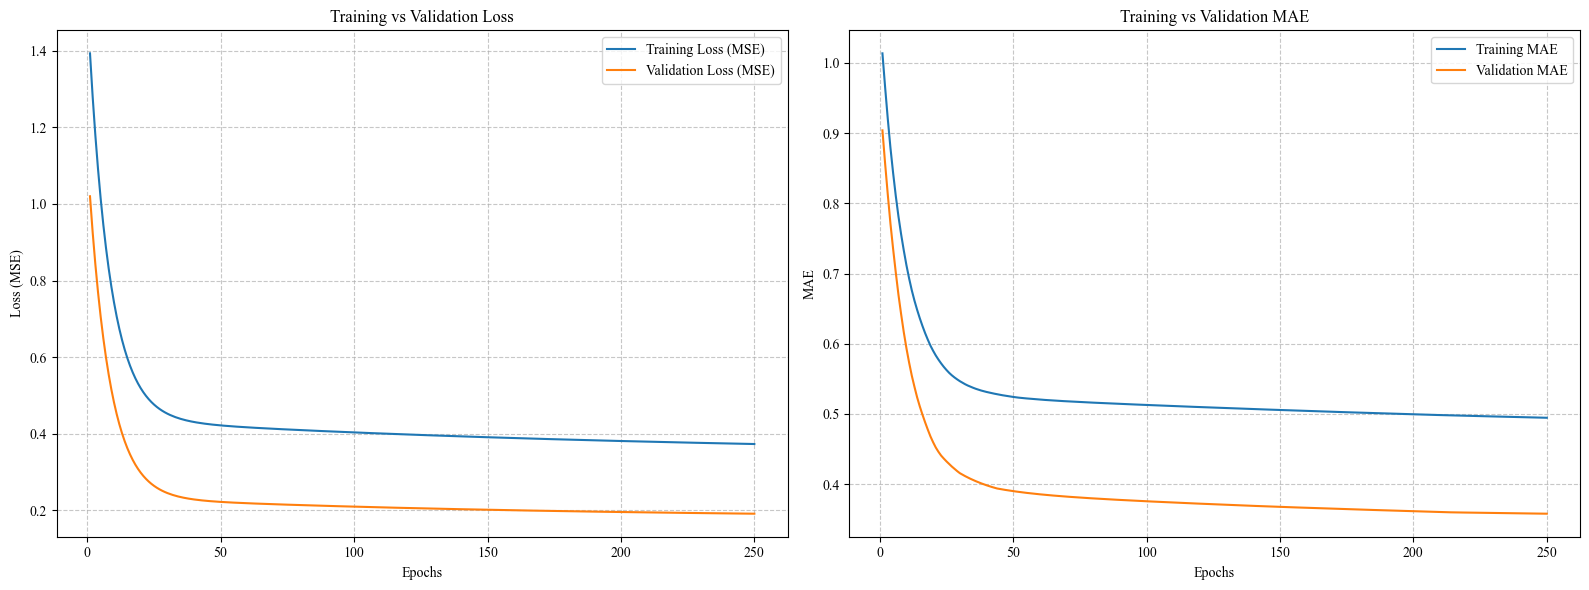

In [1]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt

# ---  Data Extraction and Prep ---
def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith("L set:"):
                capture = True
                continue
            if line.startswith("B vector:"):
                capture = False
                break
            if capture and line.startswith("["):
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

# Load data 
train_filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
train_data= np.array(extract_L_set(train_filePath))
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
test_data = np.array(extract_L_set(test_filepath))

X_full = train_data[:, :5]
y_full = train_data[:, 5].reshape(-1, 1) # Keep continuous for MSE
X_test = test_data[:, :5]
y_test = test_data[:, 5].reshape(-1, 1)

split_idx = int(0.8 * len(X_full))
X_train = X_full[:split_idx]
y_train = y_full[:split_idx]
X_val = X_full[split_idx:]
y_val = y_full[split_idx:]

# Normalize inputs
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

# ---  Network Initialization ---
input_size = 5
hidden_size = 16
output_size = 1
# tau = 1.4

np.random.seed(0)
W_h = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
W_o = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b_o = np.zeros((1, output_size))
B_h = np.random.randn(1, hidden_size) * 0.01

def hidden_sigmoid(x):
    return 1.0 / (1.0 + np.exp( -  x))

def forward(X):
    H = hidden_sigmoid(X @ W_h + B_h)
    logits = H @ W_o + b_o
    return H, logits

# New Loss and Metric Functions
def mean_squared_error(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def mean_absolute_error(y_pred, y_true):
    return np.mean(np.abs(y_pred - y_true))

# ---  Training Loop ---
learning_rate = 0.006
epochs = 250
patience = 10
best_val_loss = np.inf
patience_counter = 0
epoch_log = []

for epoch in range(epochs):
    # Forward pass
    H, logits = forward(X_train_n)
    
    # Calculate MSE Loss
    loss = mean_squared_error(logits, y_train)
    
    # Backpropagation for MSE
    # Gradient of MSE is: 2 * (y_pred - y_true) / N
    d_logits = 2.0 * (logits - y_train) / X_train_n.shape[0]
    
    dW_o = H.T @ d_logits
    db_o = np.sum(d_logits, axis=0, keepdims=True)
    dH = d_logits @ W_o.T
    dZ_h = dH * ( H * (1 - H))
    dW_h = X_train_n.T @ dZ_h
    dB_h = np.sum(dZ_h, axis=0, keepdims=True)
    
    # Update Weights
    W_o -= learning_rate * dW_o
    b_o -= learning_rate * db_o
    W_h -= learning_rate * dW_h
    B_h -= learning_rate * dB_h
    
    # Validation
    _, val_logits = forward(X_val_n)
    val_loss = mean_squared_error(val_logits, y_val)
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
        
    # Metrics (MAE)
    train_mae = mean_absolute_error(logits, y_train)
    val_mae = mean_absolute_error(val_logits, y_val)
    
    epoch_log.append((epoch+1, loss, val_loss, train_mae, val_mae))
    
    print(f"Epoch {epoch+1:3d}/{epochs} _____ Loss: {loss:.4f} -- Val Loss: {val_loss:.4f} -- Train MAE: {train_mae:.4f} -- Val MAE: {val_mae:.4f}")

# --- Testing ---
_, test_logits = forward(X_test_n)
test_mae = mean_absolute_error(test_logits, y_test)
test_mse = mean_squared_error(test_logits, y_test)
print(f"\nTest MAE: {test_mae:.4f}")
print(f"\nTest MSE: {test_mse:.4f}")

# --- Visualization ---
plt.rcParams['font.family'] = 'Times New Roman'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_list = [entry[0] for entry in epoch_log]
train_loss_list = [entry[1] for entry in epoch_log]
val_loss_list = [entry[2] for entry in epoch_log]
train_mae_list = [entry[3] for entry in epoch_log]
val_mae_list = [entry[4] for entry in epoch_log]

# Subplot 1: MSE Loss
ax1.plot(epochs_list, train_loss_list, label='Training Loss (MSE)')
ax1.plot(epochs_list, val_loss_list, label='Validation Loss (MSE)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: MAE Metric
ax2.plot(epochs_list, train_mae_list, label='Training MAE')
ax2.plot(epochs_list, val_mae_list, label='Validation MAE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MAE')
ax2.set_title('Training vs Validation MAE')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

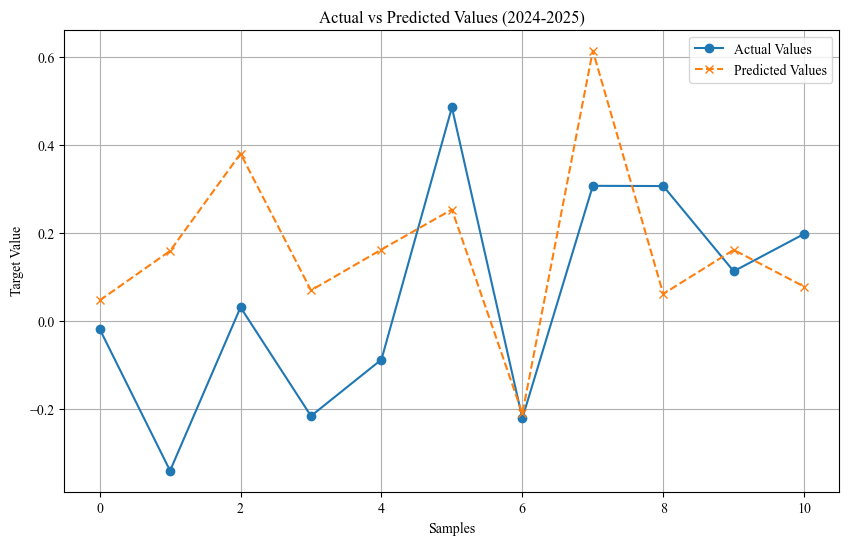

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual Values", marker="o")
plt.plot(range(len(test_logits)), test_logits.flatten(), label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025)")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import pandas as pd
# Create a comparison table
results_df = pd.DataFrame({
    'Actual Value': y_test.flatten(),
    'Predicted Value': test_logits.flatten(),
    'Direction': (((y_test.flatten() > 0) & (test_logits.flatten() > 0)) | ((y_test.flatten() < 0) & (test_logits.flatten() < 0))).astype(int)
})

print("Predictions for the 2024-2025 Test Set:")
display(results_df)
count_ones = results_df['Direction'].value_counts()[1]
print(results_df['Direction'].value_counts())
print(f"Total right direction => {count_ones}, {(count_ones/len(test_logits.flatten()))*100:.2f}%")

Predictions for the 2024-2025 Test Set:


,Actual Value,Predicted Value,Direction
0,-0.017473,0.047161,0
1,-0.339443,0.159605,0
2,0.031541,0.380585,1
3,-0.215161,0.069992,0
4,-0.087107,0.162703,0
5,0.485383,0.253530,1
6,-0.220254,-0.209419,1
7,0.307394,0.614123,1
8,0.306878,0.062096,1
9,0.113420,0.161963,1


Direction
1    7
0    4
Name: count, dtype: int64
Total right direction => 7, 63.64%
